# Deep MLP for Predictive Maintenance

## Setup

In [33]:
from pathlib import Path
import json
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import average_precision_score, brier_score_loss, classification_report
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

configration (For reproducibility)

In [34]:
SEED = 42
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20
BATCH_SIZE = 64
EPOCHS = 150
LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.30
L2_RATE = 1e-4
FALSE_NEGATIVE_COST = 10
FALSE_POSITIVE_COST = 1

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [35]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "cleaned" / "ai4i2020_cleaned.csv"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_DIR = PROJECT_ROOT / "reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

## Data and features

In [36]:
df = pd.read_csv(DATA_PATH)
display(df.head())
print(df.shape)
print(df["machine_failure"].value_counts())
print(df["machine_failure"].value_counts())

,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k,power_kw,wear_rate
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6.951079,0.000000
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6.826220,0.002131
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7.748817,0.003338
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5.927068,0.004885
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5.897382,0.006392


(10000, 17)
machine_failure
0    9661
1     339
Name: count, dtype: int64
machine_failure
0    9661
1     339
Name: count, dtype: int64


In [37]:
model_df = df.copy()
model_df["temp_ratio"] = model_df["process_temp_k"] / model_df["air_temp_k"]
model_df["torque_per_rpm"] = model_df["torque_nm"] / (model_df["rotational_speed_rpm"] + 1e-6)
model_df["torque_toolwear_interaction"] = model_df["torque_nm"] * model_df["tool_wear_min"]

In [38]:
TARGET = "machine_failure"
IDENTIFIER_COLUMNS = ["udi", "product_id"]
LEAKAGE_COLUMNS = ["twf", "hdf", "pwf", "osf", "rnf"]
DROP_COLUMNS = IDENTIFIER_COLUMNS + LEAKAGE_COLUMNS

X = model_df.drop(columns=[TARGET] + DROP_COLUMNS)
y = model_df[TARGET].astype("int32")

print(X.shape)
display(X.head())

(10000, 12)


,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,temp_diff_k,power_kw,wear_rate,temp_ratio,torque_per_rpm,torque_toolwear_interaction
0,M,298.1,308.6,1551,42.8,0,10.5,6.951079,0.000000,1.035223,0.027595,0.0
1,L,298.2,308.7,1408,46.3,3,10.5,6.826220,0.002131,1.035211,0.032884,138.9
2,L,298.1,308.5,1498,49.4,5,10.4,7.748817,0.003338,1.034888,0.032977,247.0
3,L,298.2,308.6,1433,39.5,7,10.4,5.927068,0.004885,1.034876,0.027565,276.5
4,L,298.2,308.7,1408,40.0,9,10.5,5.897382,0.006392,1.035211,0.028409,360.0


## Train, validation, and test split

In [39]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=VALIDATION_SIZE,
    stratify=y_train_val,
    random_state=SEED,
)

In [40]:
split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_val), len(X_test)],
        "failures": [y_train.sum(), y_val.sum(), y_test.sum()],
        "failure_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)
display(split_summary)

,rows,failures,failure_rate
train,6400,217,0.033906
validation,1600,54,0.033750
test,2000,68,0.034000


In [41]:
split_assignments = pd.DataFrame({"udi": df["udi"], "split": ""})
split_assignments.loc[X_train.index, "split"] = "train"
split_assignments.loc[X_val.index, "split"] = "validation"
split_assignments.loc[X_test.index, "split"] = "test"
split_assignments.to_csv(REPORT_DIR / "deep_mlp_split.csv", index=False)

## Preprocessing

In [42]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)

In [43]:
X_train_processed = preprocessor.fit_transform(X_train).astype("float32")
X_val_processed = preprocessor.transform(X_val).astype("float32")
X_test_processed = preprocessor.transform(X_test).astype("float32")
feature_names = preprocessor.get_feature_names_out().tolist()

print(X_train_processed.shape)
print(feature_names)

(6400, 14)
['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'temp_diff_k', 'power_kw', 'wear_rate', 'temp_ratio', 'torque_per_rpm', 'torque_toolwear_interaction', 'type_H', 'type_L', 'type_M']


In [44]:
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)
class_weights = dict(zip(classes, weights))
class_weights

{0: 0.5175481158013909, 1: 14.746543778801843}

## Deep MLP

In [45]:
def build_mlp(input_dim):
    regularizer = tf.keras.regularizers.l2(L2_RATE)
    inputs = tf.keras.Input(shape=(input_dim,), name="features")
    x = tf.keras.layers.Dense(128, kernel_regularizer=regularizer)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(DROPOUT_RATE)(x)
    x = tf.keras.layers.Dense(64, kernel_regularizer=regularizer)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(DROPOUT_RATE)(x)
    x = tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=regularizer)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="failure_probability")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="predictive_maintenance_mlp")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
            tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model

In [46]:
model = build_mlp(X_train_processed.shape[1])
model.summary()

Model: "predictive_maintenance_mlp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 features (InputLayer)       [(None, 14)]              0         
                                                                 
 dense_3 (Dense)             (None, 128)               1920      
                                                                 
 batch_normalization_2 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 activation_2 (Activation)   (None, 128)               0         
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                        

In [47]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=20,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_pr_auc",
        mode="max",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_DIR / "deep_mlp_best.keras",
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
    ),
]

In [48]:
history = model.fit(
    X_train_processed,
    y_train.to_numpy(),
    validation_data=(X_val_processed, y_val.to_numpy()),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/150
100/100 [==============================] - 2s 7ms/step - loss: 0.5692 - pr_auc: 0.2127 - roc_auc: 0.8069 - precision: 0.0691 - recall: 0.8387 - val_loss: 0.5983 - val_pr_auc: 0.5344 - val_roc_auc: 0.9248 - val_precision: 0.0887 - val_recall: 0.8704 - lr: 0.0010
Epoch 2/150
100/100 [==============================] - 1s 5ms/step - loss: 0.4322 - pr_auc: 0.3479 - roc_auc: 0.8963 - precision: 0.1182 - recall: 0.8525 - val_loss: 0.4753 - val_pr_auc: 0.5676 - val_roc_auc: 0.9382 - val_precision: 0.1294 - val_recall: 0.8889 - lr: 0.0010
Epoch 3/150
100/100 [==============================] - 0s 3ms/step - loss: 0.3675 - pr_auc: 0.4101 - roc_auc: 0.9261 - precision: 0.1522 - recall: 0.8756 - val_loss: 0.3882 - val_pr_auc: 0.6119 - val_roc_auc: 0.9449 - val_precision: 0.1549 - val_recall: 0.8519 - lr: 0.0010
Epoch 4/150
100/100 [==============================] - 0s 3ms/step - loss: 0.3688 - pr_auc: 0.3796 - roc_auc: 0.9228 - precision: 0.1526 - recall: 0.8571 - val_loss: 0.3843 - val

## Training results

In [49]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(REPORT_DIR / "deep_mlp_training_history.csv", index=False)
display(history_df.tail())

,loss,pr_auc,roc_auc,precision,recall,val_loss,val_pr_auc,val_roc_auc,val_precision,val_recall,lr
42,0.237097,0.631822,0.969228,0.232749,0.917051,0.235392,0.726709,0.958603,0.237624,0.888889,0.000063
43,0.239620,0.644385,0.969246,0.248447,0.921659,0.235554,0.726479,0.959226,0.237624,0.888889,0.000063
44,0.234849,0.633771,0.970212,0.245700,0.921659,0.238682,0.730263,0.958747,0.233010,0.888889,0.000063
45,0.257181,0.657277,0.964965,0.241126,0.907834,0.237671,0.729962,0.958405,0.235294,0.888889,0.000063
46,0.232695,0.624406,0.970583,0.241667,0.935484,0.240613,0.725941,0.958465,0.234146,0.888889,0.000063


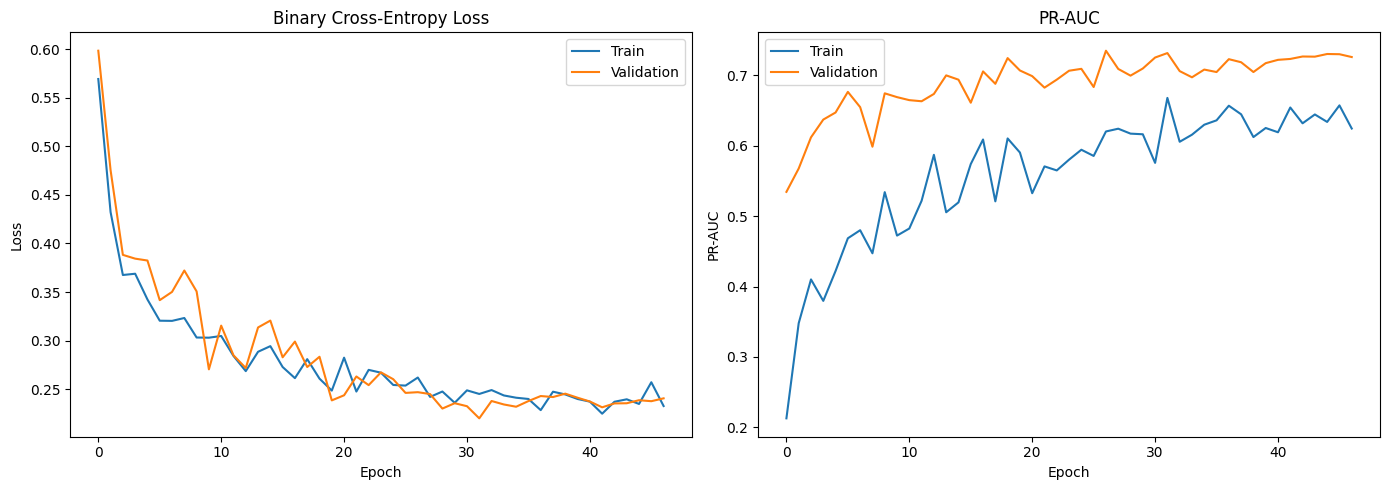

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_df["loss"], label="Train")
axes[0].plot(history_df["val_loss"], label="Validation")
axes[0].set_title("Binary Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(history_df["pr_auc"], label="Train")
axes[1].plot(history_df["val_pr_auc"], label="Validation")
axes[1].set_title("PR-AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("PR-AUC")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "deep_mlp_training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

## Calibration and threshold optimization

In [51]:
validation_probabilities_raw = model.predict(X_val_processed, verbose=0).ravel()
test_probabilities_raw = model.predict(X_test_processed, verbose=0).ravel()

In [52]:
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(validation_probabilities_raw, y_val.to_numpy())
validation_probabilities = calibrator.predict(validation_probabilities_raw)
test_probabilities = calibrator.predict(test_probabilities_raw)

In [53]:
def threshold_metrics(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "false_negative_rate": fn / (fn + tp) if fn + tp else 0.0,
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "cost": int(fn * FALSE_NEGATIVE_COST + fp * FALSE_POSITIVE_COST),
    }

In [54]:
threshold_table = pd.DataFrame(
    [
        threshold_metrics(y_val, validation_probabilities, threshold)
        for threshold in np.linspace(0.01, 0.99, 99)
    ]
)
best_threshold = float(
    threshold_table.sort_values(
        ["cost", "false_negatives", "threshold"],
        ascending=[True, True, False],
    ).iloc[0]["threshold"]
)
threshold_table.to_csv(REPORT_DIR / "deep_mlp_threshold_search.csv", index=False)
display(threshold_table.sort_values("cost").head(10))
print(best_threshold)

,threshold,precision,recall,f1,false_negative_rate,false_positives,false_negatives,cost
4,0.05,0.453608,0.814815,0.582781,0.185185,53,10,153
5,0.06,0.453608,0.814815,0.582781,0.185185,53,10,153
6,0.07,0.453608,0.814815,0.582781,0.185185,53,10,153
7,0.08,0.453608,0.814815,0.582781,0.185185,53,10,153
8,0.09,0.453608,0.814815,0.582781,0.185185,53,10,153
9,0.10,0.453608,0.814815,0.582781,0.185185,53,10,153
22,0.23,0.594203,0.759259,0.666667,0.240741,28,13,158
24,0.25,0.594203,0.759259,0.666667,0.240741,28,13,158
23,0.24,0.594203,0.759259,0.666667,0.240741,28,13,158
21,0.22,0.594203,0.759259,0.666667,0.240741,28,13,158


0.09999999999999999


## Test evaluation

In [55]:
test_predictions = (test_probabilities >= best_threshold).astype(int)
test_confusion_matrix = confusion_matrix(y_test, test_predictions, labels=[0, 1])
test_metrics = threshold_metrics(y_test, test_probabilities, best_threshold)
test_metrics.update(
    {
        "model": "Deep MLP",
        "pr_auc": average_precision_score(y_test, test_probabilities),
        "roc_auc": roc_auc_score(y_test, test_probabilities),
        "brier_score_raw": brier_score_loss(y_test, test_probabilities_raw),
        "brier_score_calibrated": brier_score_loss(y_test, test_probabilities),
    }
)
display(pd.DataFrame([test_metrics]).set_index("model").T)
print(classification_report(y_test, test_predictions, digits=4, zero_division=0))

model,Deep MLP
threshold,0.100000
precision,0.451613
recall,0.823529
f1,0.583333
false_negative_rate,0.176471
false_positives,68.000000
false_negatives,12.000000
cost,188.000000
pr_auc,0.683542
roc_auc,0.965290


              precision    recall  f1-score   support

           0     0.9936    0.9648    0.9790      1932
           1     0.4516    0.8235    0.5833        68

    accuracy                         0.9600      2000
   macro avg     0.7226    0.8942    0.7812      2000
weighted avg     0.9752    0.9600    0.9655      2000



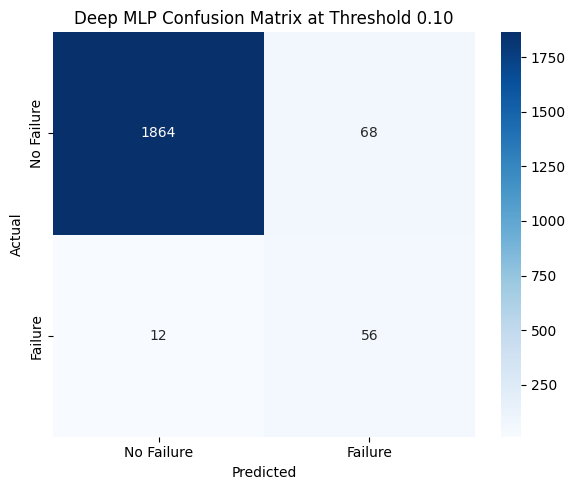

In [56]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    test_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"],
)
plt.title(f"Deep MLP Confusion Matrix at Threshold {best_threshold:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "deep_mlp_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

In [57]:
raw_fraction_positive, raw_mean_prediction = calibration_curve(
    y_test,
    test_probabilities_raw,
    n_bins=10,
    strategy="quantile",
)
calibrated_fraction_positive, calibrated_mean_prediction = calibration_curve(
    y_test,
    test_probabilities,
    n_bins=10,
    strategy="quantile",
)

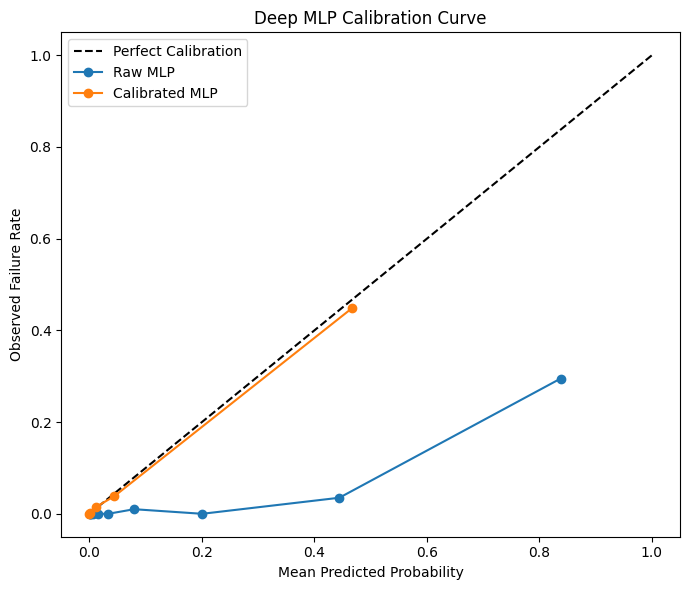

In [58]:
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect Calibration")
plt.plot(raw_mean_prediction, raw_fraction_positive, marker="o", label="Raw MLP")
plt.plot(
    calibrated_mean_prediction,
    calibrated_fraction_positive,
    marker="o",
    label="Calibrated MLP",
)
plt.title("Deep MLP Calibration Curve")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Failure Rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "deep_mlp_calibration_curve.png", dpi=200, bbox_inches="tight")
plt.show()

## Export artifacts and compare with classical ML

In [59]:
model.save(MODEL_DIR / "deep_mlp_final.keras")
joblib.dump(preprocessor, MODEL_DIR / "deep_mlp_preprocessor.joblib")
joblib.dump(calibrator, MODEL_DIR / "deep_mlp_calibrator.joblib")
pd.DataFrame([test_metrics]).to_csv(REPORT_DIR / "deep_mlp_metrics.csv", index=False)

In [60]:
metadata = {
    "model_name": "Deep MLP",
    "model_version": "v0.1.0",
    "input_schema_version": "v1",
    "random_seed": SEED,
    "target": TARGET,
    "input_features": X.columns.tolist(),
    "processed_features": feature_names,
    "excluded_identifiers": IDENTIFIER_COLUMNS,
    "excluded_leakage_features": LEAKAGE_COLUMNS,
    "decision_threshold": best_threshold,
    "false_negative_cost": FALSE_NEGATIVE_COST,
    "false_positive_cost": FALSE_POSITIVE_COST,
    "split_sizes": split_summary["rows"].to_dict(),
}

with open(MODEL_DIR / "deep_mlp_metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

In [61]:
classical_results_path = REPORT_DIR / "classical_ml_metrics.csv"
mlp_results = pd.DataFrame([test_metrics])

if classical_results_path.exists():
    classical_results = pd.read_csv(classical_results_path)
    comparison = pd.concat([classical_results, mlp_results], ignore_index=True, sort=False)
    comparison.to_csv(REPORT_DIR / "ml_vs_dl_comparison.csv", index=False)
    display(comparison)
else:
    display(mlp_results)
    print(f"Add classical results at {classical_results_path}")

,threshold,precision,recall,f1,false_negative_rate,false_positives,false_negatives,cost,model,pr_auc,roc_auc,brier_score_raw,brier_score_calibrated
0,0.1,0.451613,0.823529,0.583333,0.176471,68,12,188,Deep MLP,0.683542,0.96529,0.07226,0.015928


Add classical results at D:\Coding\Main\Python\Tech Trek\Project 2\team-225-predictive-maintenance\reports\classical_ml_metrics.csv
